# APPA-REAL 年龄估计 Notebook

本 notebook 是计算机视觉课程大实验的一键运行入口。它会在同一套数据集、评价指标和结果保存流程下，验证 DenseNet121、改进版 ViT-B/16，以及 baseline ViT-B/16 三个模型。

设计原则：核心训练、测试、模型构建、数据读取均保留在原始工程代码中；notebook 只做环境检查、路径定位、调用 `main.py --mode test`、读取与展示结果，不在 notebook 中重写训练或评估算法。

使用方法：将 APPA-REAL 数据集放到 `data/appa-real-release/`，选择正确的 Jupyter 内核，然后点击 Run All。若当前机器没有数据集，notebook 会自动退回到展示模式，读取 `results/` 中已经保存的实验结果，保证仍可展示报告结论。

In [1]:
from __future__ import annotations

import os
import shutil
import subprocess
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    """从当前 notebook 工作目录向上寻找项目根目录。"""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "main.py").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("无法定位项目根目录。请从项目根目录或 notebooks 目录启动 Jupyter。")


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"项目根目录: {PROJECT_ROOT}")
print(f"当前 Python: {sys.executable}")

项目根目录: E:\06-ZYZ-CV\0-CV Experiment
当前 Python: d:\Miniforge3\envs\cv-age\python.exe


## 1. 参数设置

通常不需要修改路径。推荐将数据集放在 `data/appa-real-release/`。如果组员把数据集放在其他位置，可以设置环境变量 `APPA_REAL_ROOT`，或者直接修改下面的 `DATA_ROOT_OVERRIDE`。

In [2]:
MODELS = ["densenet", "vit", "vit_baseline"]

# 可选：如果数据集不在本项目目录内，可以在这里填写绝对路径。
# 保持为 None 时，会自动查找 APPA_REAL_ROOT / AGE_DATA_ROOT / 项目内相对路径。
DATA_ROOT_OVERRIDE = None

DATA_ROOT_CANDIDATES = []
for env_name in ["APPA_REAL_ROOT", "AGE_DATA_ROOT"]:
    env_value = os.environ.get(env_name)
    if env_value:
        DATA_ROOT_CANDIDATES.append(Path(env_value))
if DATA_ROOT_OVERRIDE:
    DATA_ROOT_CANDIDATES.append(Path(DATA_ROOT_OVERRIDE))
DATA_ROOT_CANDIDATES.extend([
    PROJECT_ROOT / "data" / "appa-real-release",
    PROJECT_ROOT / "data" / "appa-real",
    PROJECT_ROOT / "data" / "APPA-REAL",
])

# 如果检测到数据集，则调用 main.py --mode test 进行测试集验证；否则展示已有 results/ 结果。
# 当前先用于安全展示验证：False 表示只展示已有结果，不重新跑测试集；需要完整测试集验证时改为 True。
RUN_EVALUATION_IF_DATA_AVAILABLE = False

# 缺少运行依赖时是否自动安装。
INSTALL_MISSING_DEPENDENCIES = True

NOTEBOOK_RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_run"
NOTEBOOK_CKPT_DIR = PROJECT_ROOT / "checkpoints_notebook"

print("模型列表:", MODELS)
print("notebook 输出目录:", NOTEBOOK_RESULTS_DIR)

模型列表: ['densenet', 'vit', 'vit_baseline']
notebook 输出目录: E:\06-ZYZ-CV\0-CV Experiment\results\notebook_run


## 2. 环境检查

In [3]:
def ensure_runtime_dependencies(required: bool = False, include_torch: bool = True) -> bool:
    pairs = [
        ("matplotlib", "matplotlib"),
        ("pandas", "pandas"),
        ("numpy", "numpy"),
        ("Pillow", "PIL"),
        ("tqdm", "tqdm"),
    ]
    if include_torch:
        pairs = [("torch", "torch"), ("torchvision", "torchvision"), ("pyyaml", "yaml")] + pairs

    missing = []
    for package_name, import_name in pairs:
        try:
            __import__(import_name)
        except Exception:
            missing.append(package_name)

    if missing and required and INSTALL_MISSING_DEPENDENCIES:
        install_cmd = [sys.executable, "-m", "pip", "install"]
        if include_torch:
            install_cmd += ["-r", "requirements.txt"]
        else:
            install_cmd += missing
        subprocess.run(install_cmd, check=True)
        missing = []
        for package_name, import_name in pairs:
            try:
                __import__(import_name)
            except Exception:
                missing.append(package_name)

    if missing and required:
        raise RuntimeError("缺少依赖包: " + ", ".join(missing) + "。请先运行: pip install -r requirements.txt")
    if missing:
        print("深度学习运行依赖尚未安装，但仍可展示已有 results/ 结果:", ", ".join(missing))
        return False

    if not include_torch:
        print("展示与汇总所需依赖已就绪。")
        return True

    import torch
    import torchvision

    print("torch 版本:", torch.__version__)
    print("torchvision 版本:", torchvision.__version__)
    print("是否可用 CUDA:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    return True


DISPLAY_DEPENDENCIES_READY = ensure_runtime_dependencies(required=True, include_torch=False)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# Notebook self-drawn plots use English titles to avoid CJK font glyph warnings.
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False


展示与汇总所需依赖已就绪。


## 3. 数据集与权重定位

In [4]:
def looks_like_appa_real(root: Path) -> bool:
    required_csv = [root / f"gt_avg_{split}.csv" for split in ["train", "valid", "test"]]
    required_dirs = [root / split for split in ["train", "valid", "test"]]
    return all(path.exists() for path in required_csv + required_dirs)


def find_data_root() -> Path | None:
    for candidate in DATA_ROOT_CANDIDATES:
        candidate = candidate.expanduser().resolve()
        if looks_like_appa_real(candidate):
            return candidate
    return None


def find_checkpoint_source_root() -> Path:
    candidates = [
        PROJECT_ROOT / "checkpoints_backup" / "checkpoints_backup",
        PROJECT_ROOT / "checkpoints_backup",
        PROJECT_ROOT / "checkpoints",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("未找到 checkpoints_backup 或 checkpoints 目录。")


DATA_ROOT = find_data_root()
CKPT_SOURCE_ROOT = find_checkpoint_source_root()

if DATA_ROOT is None:
    print("未检测到 APPA-REAL 数据集，将展示 results/ 中已有结果。")
else:
    print("APPA-REAL 数据集路径:", DATA_ROOT)
print("checkpoint 来源目录:", CKPT_SOURCE_ROOT)

APPA-REAL 数据集路径: E:\06-ZYZ-CV\0-CV Experiment\data\appa-real-release
checkpoint 来源目录: E:\06-ZYZ-CV\0-CV Experiment\checkpoints_backup\checkpoints_backup


In [5]:
CKPT_BACKUP_NAMES = {
    "densenet": ["densenet_50ep_best.pth", "densenet_best.pth"],
    "vit": ["vit_50ep_best.pth", "vit_best.pth"],
    "vit_baseline": ["vit_baseline_50ep_best.pth", "vit_baseline_best.pth"],
}


def prepare_checkpoints(models: list[str]) -> pd.DataFrame:
    NOTEBOOK_CKPT_DIR.mkdir(parents=True, exist_ok=True)
    restored = []
    for model in models:
        dst = NOTEBOOK_CKPT_DIR / f"{model}_best.pth"
        if dst.exists():
            restored.append((model, dst, "已存在"))
            continue

        found = None
        for name in CKPT_BACKUP_NAMES[model]:
            candidate = CKPT_SOURCE_ROOT / name
            if candidate.exists():
                found = candidate
                break
        if found is None:
            raise FileNotFoundError(f"在 {CKPT_SOURCE_ROOT} 下未找到 {model} 的 best checkpoint")

        shutil.copy2(found, dst)
        restored.append((model, dst, f"从 {found.name} 复制"))

    return pd.DataFrame(restored, columns=["模型", "标准 checkpoint 路径", "状态"])


if DATA_ROOT is not None and RUN_EVALUATION_IF_DATA_AVAILABLE:
    ensure_runtime_dependencies(required=True, include_torch=True)
    ckpt_df = prepare_checkpoints(MODELS)
    display(ckpt_df)
else:
    print("当前跳过 checkpoint 准备；进行测试集验证或单图推理时会按需准备。")

当前跳过 checkpoint 准备；进行测试集验证或单图推理时会按需准备。


## 4. 一键测试集验证（调用 main.py 原始入口）

如果已经检测到数据集，本节会依次执行原始工程入口：

`python main.py --model <model> --mode test --ckpt_dir checkpoints_notebook --out_dir results/notebook_run`

因此本节只做测试集评估，不训练模型，也不修改 `configs/*.yaml` 或 `checkpoints_backup/`。

In [6]:
def run_model_test(model: str) -> None:
    cmd = [
        sys.executable,
        "main.py",
        "--model",
        model,
        "--mode",
        "test",
        "--data_root",
        str(DATA_ROOT),
        "--ckpt_dir",
        str(NOTEBOOK_CKPT_DIR),
        "--out_dir",
        str(NOTEBOOK_RESULTS_DIR),
    ]
    print("\n$", " ".join(cmd))
    subprocess.run(cmd, check=True)


if DATA_ROOT is not None and RUN_EVALUATION_IF_DATA_AVAILABLE:
    for model in MODELS:
        run_model_test(model)
else:
    print("跳过测试集验证：数据集不存在，或 RUN_EVALUATION_IF_DATA_AVAILABLE=False。")

跳过测试集验证：数据集不存在，或 RUN_EVALUATION_IF_DATA_AVAILABLE=False。


## 5. 指标汇总

In [7]:
def parse_summary(path: Path) -> dict:
    values = {}
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        if ":" not in line:
            continue
        key, value = line.split(":", 1)
        values[key.strip()] = value.strip()
    return values


def find_model_result_dir(model: str) -> Path | None:
    candidates = [
        NOTEBOOK_RESULTS_DIR / model,
        PROJECT_ROOT / "results" / model,
        PROJECT_ROOT / "results" / f"{model}_100ep",
        PROJECT_ROOT / "results" / f"{model}_25ep",
    ]
    for candidate in candidates:
        if (candidate / "test_summary.txt").exists():
            return candidate
    return None


rows = []
for model in MODELS:
    result_dir = find_model_result_dir(model)
    if result_dir is None:
        continue
    summary = parse_summary(result_dir / "test_summary.txt")
    rows.append({
        "模型": model,
        "结果目录": str(result_dir.relative_to(PROJECT_ROOT)),
        "最佳 epoch": summary.get("best_epoch", ""),
        "测试集 MAE": float(summary.get("test_mae", "nan")),
        "测试集 RMSE": float(summary.get("test_rmse", "nan")),
        "测试样本数": int(float(summary.get("n_test", "0"))),
    })

summary_df = pd.DataFrame(rows)
if summary_df.empty:
    comparison_csv = PROJECT_ROOT / "results" / "comparison" / "comparison_table.csv"
    summary_df = pd.read_csv(comparison_csv)

display(summary_df)

,模型,结果目录,最佳 epoch,测试集 MAE,测试集 RMSE,测试样本数
0,densenet,results\densenet,31,4.940920,6.942903,1978
1,vit,results\vit,37,4.860518,6.943111,1978
2,vit_baseline,results\vit_baseline,45,9.442189,13.134458,1978


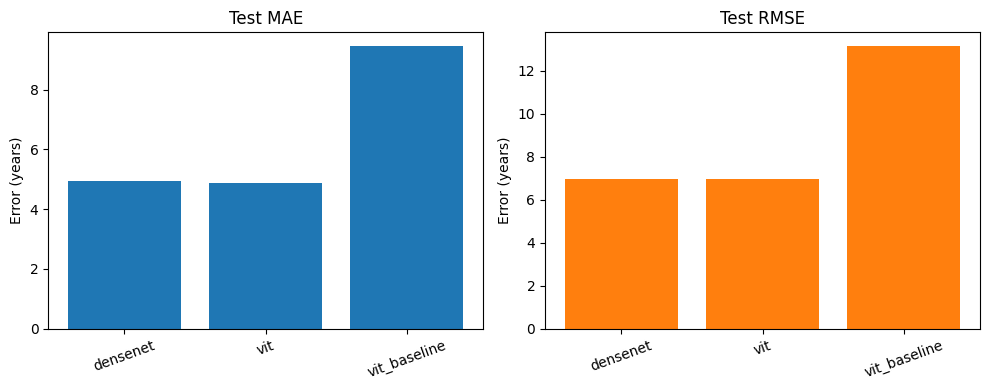

In [8]:
model_col = "\u6a21\u578b"
mae_col = "\u6d4b\u8bd5\u96c6 MAE"
rmse_col = "\u6d4b\u8bd5\u96c6 RMSE"

if {model_col, mae_col, rmse_col}.issubset(summary_df.columns):
    plot_df = summary_df.copy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(plot_df[model_col].astype(str), plot_df[mae_col].astype(float))
    axes[0].set_title("Test MAE")
    axes[0].set_ylabel("Error (years)")
    axes[0].tick_params(axis="x", rotation=20)
    axes[1].bar(plot_df[model_col].astype(str), plot_df[rmse_col].astype(float), color="tab:orange")
    axes[1].set_title("Test RMSE")
    axes[1].set_ylabel("Error (years)")
    axes[1].tick_params(axis="x", rotation=20)
    fig.tight_layout()
    plt.show()
else:
    display(summary_df)


## 6. 三模型性能对比结果

本节展示原始实验已经生成的三模型对比成果，图片均来自 `results/comparison/`。这些图不是 notebook 重新绘制的，而是直接读取原实验保存的对比图。

,model,epochs_run,best_epoch_by_val_mae,best_val_mae,best_val_rmse,final_val_mae,test_mae,test_rmse,n_test,pred_std,pearson_r,mean_epoch_time_sec,gpu_mem_peak_mb
0,DenseNet121 (50ep),50,31,4.098286,6.302032,4.181094,4.940920,6.942903,1978,15.259916,0.925013,9.257379,4122.578613
1,"ViT-B/16 (LLRD+warmup, 50ep)",50,37,4.126955,6.195672,4.198540,4.860683,6.943314,1978,15.273855,0.924376,36.180536,2990.807129
2,"ViT-B/16 (default recipe, 50ep)",50,45,7.628778,10.699316,7.648081,9.442189,13.134458,1978,11.543868,0.695606,36.092877,2989.807129


**Predicted vs. Ground Truth: Three-Panel Comparison**

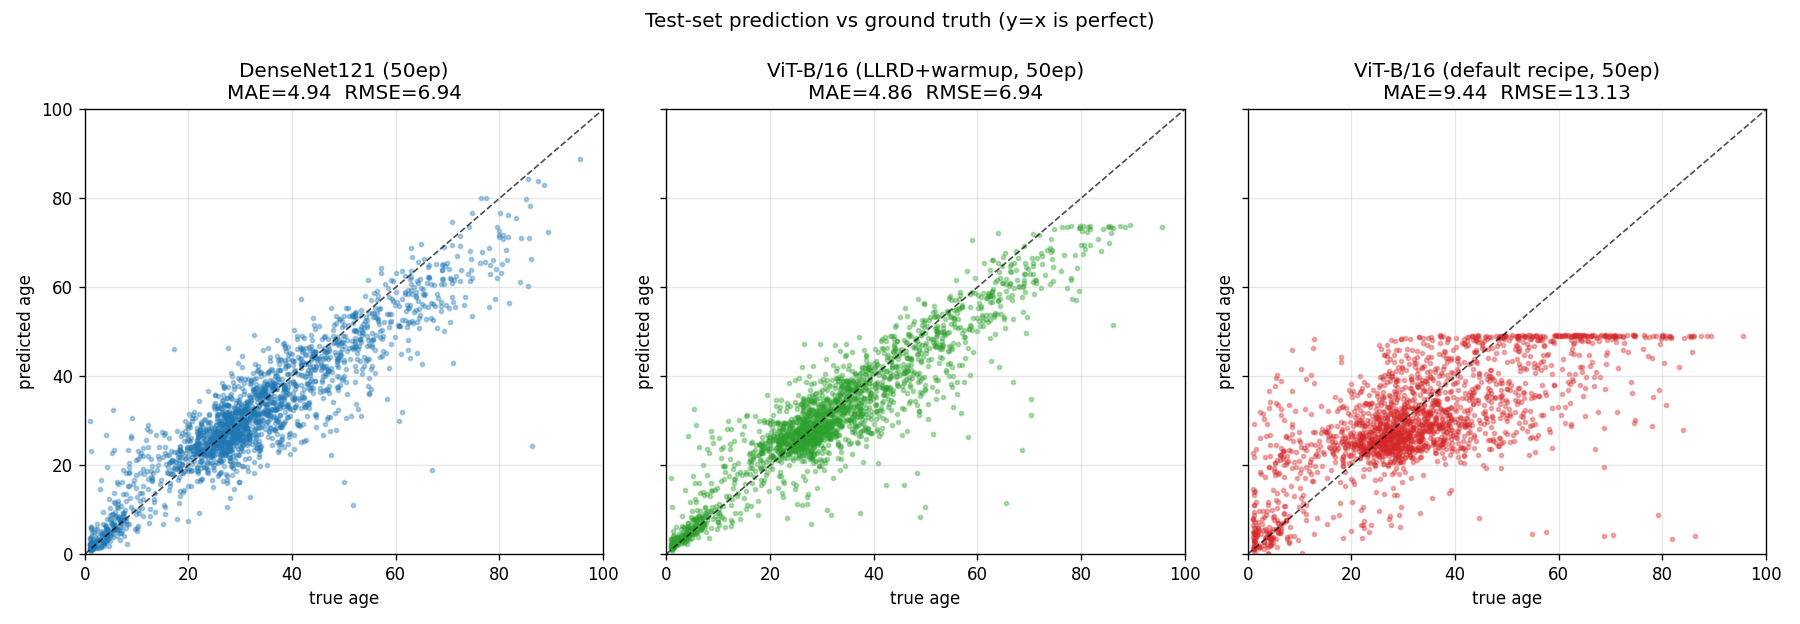

**Prediction Distribution Comparison**

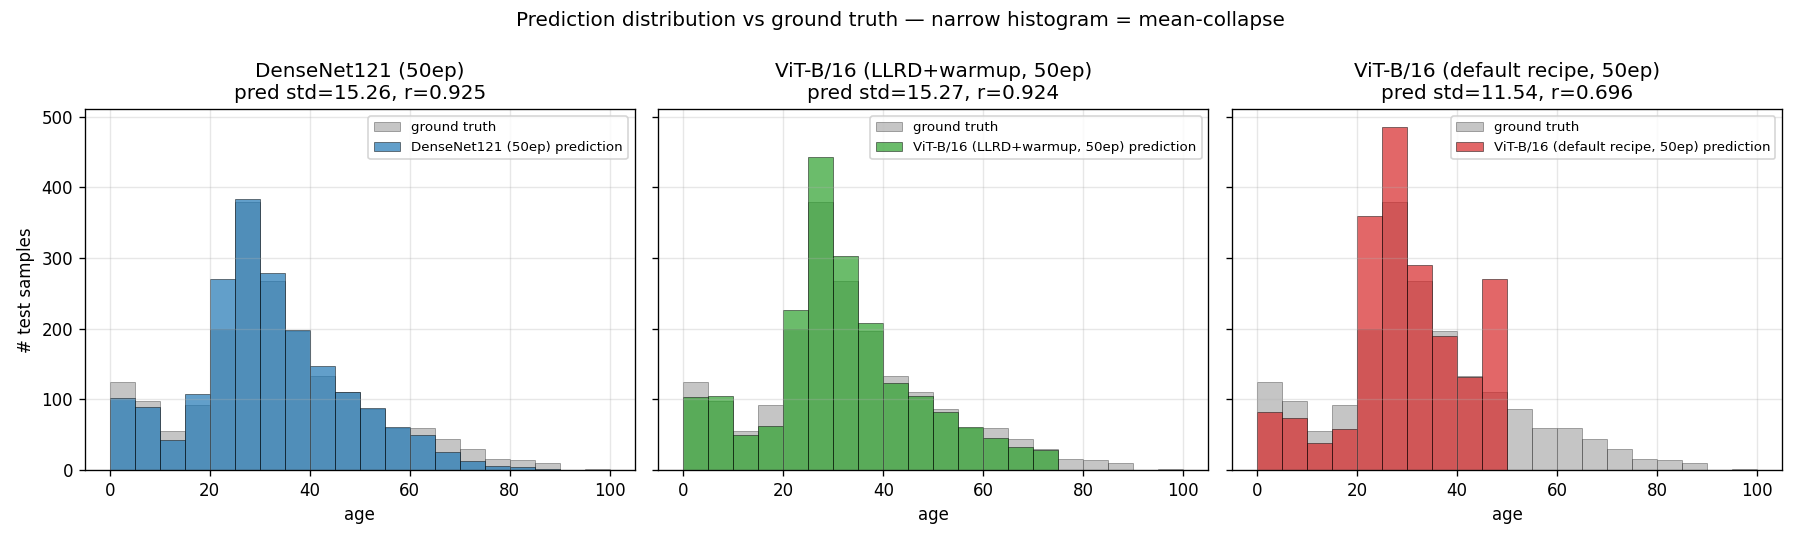

**Per-Age-Group MAE Comparison**

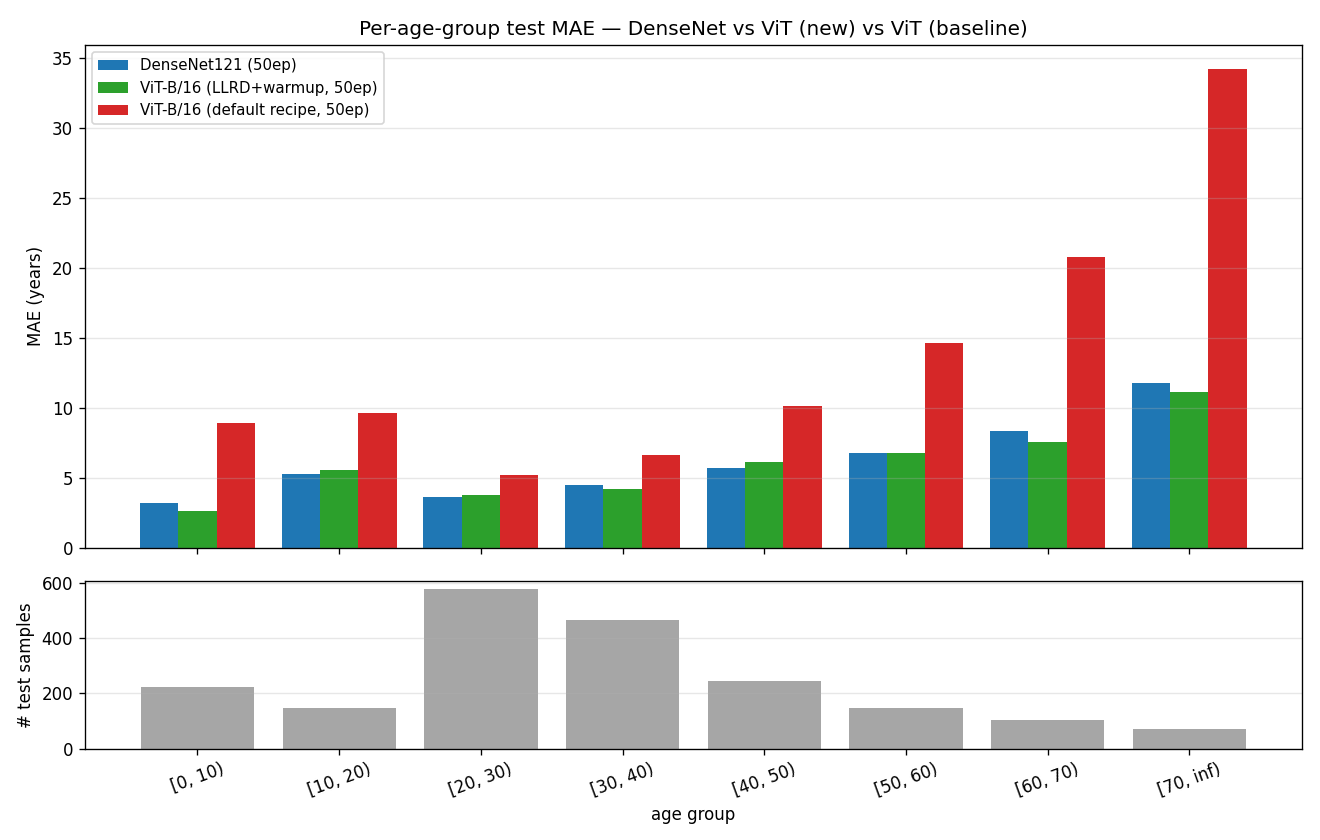

**Validation MAE Curves Overlay**

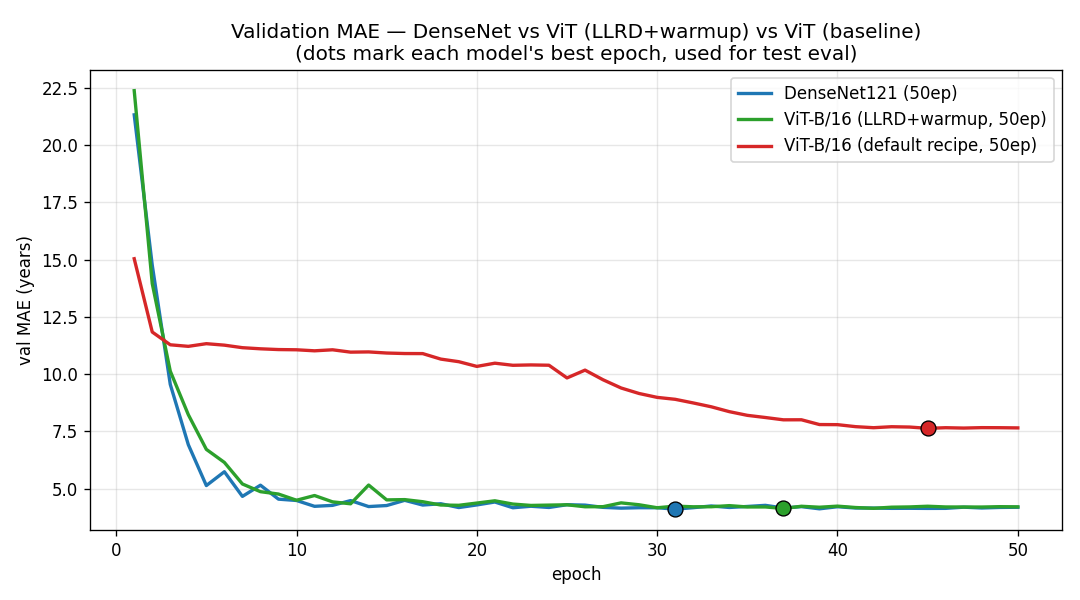

**Loss Curves Overlay**

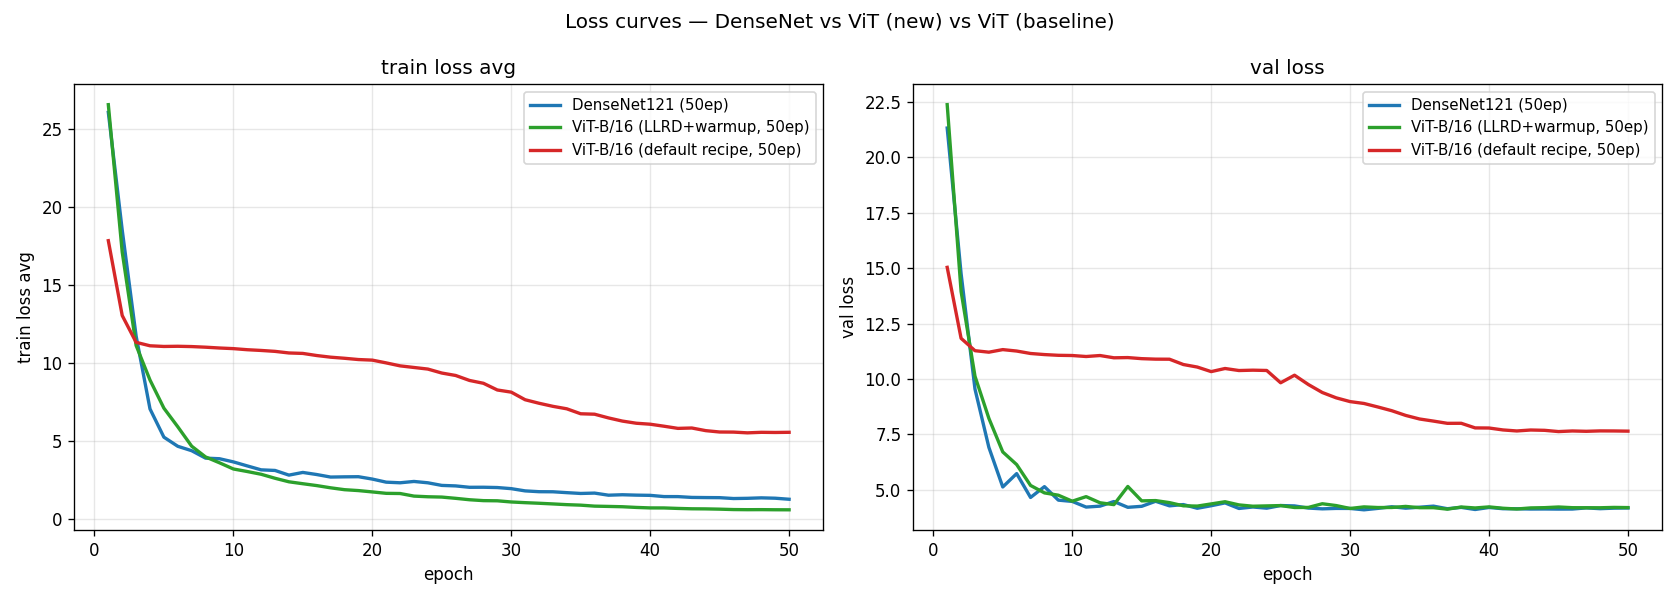

**Budget Extension: MAE Curves**

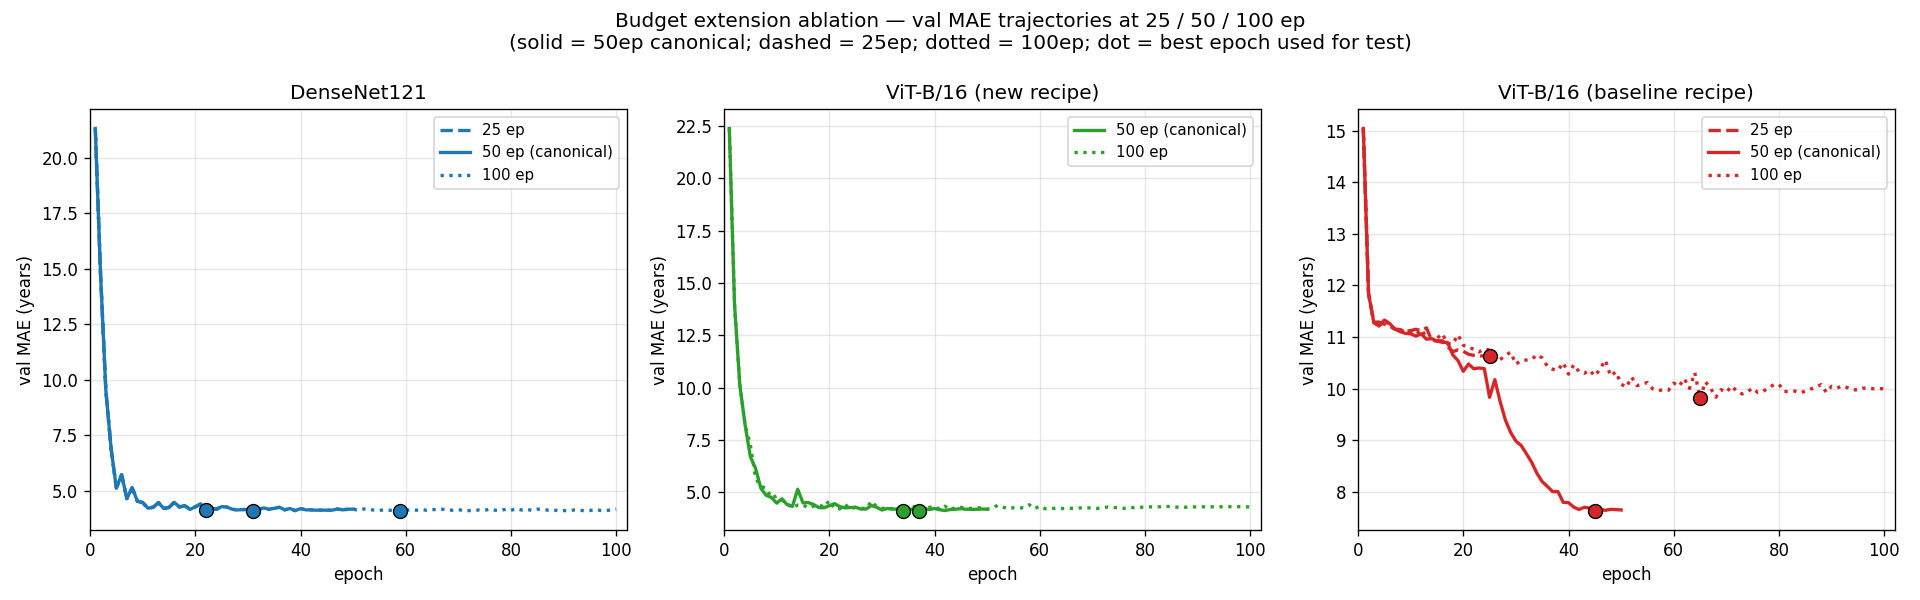

**Budget Extension: Baseline Per-Age MAE**

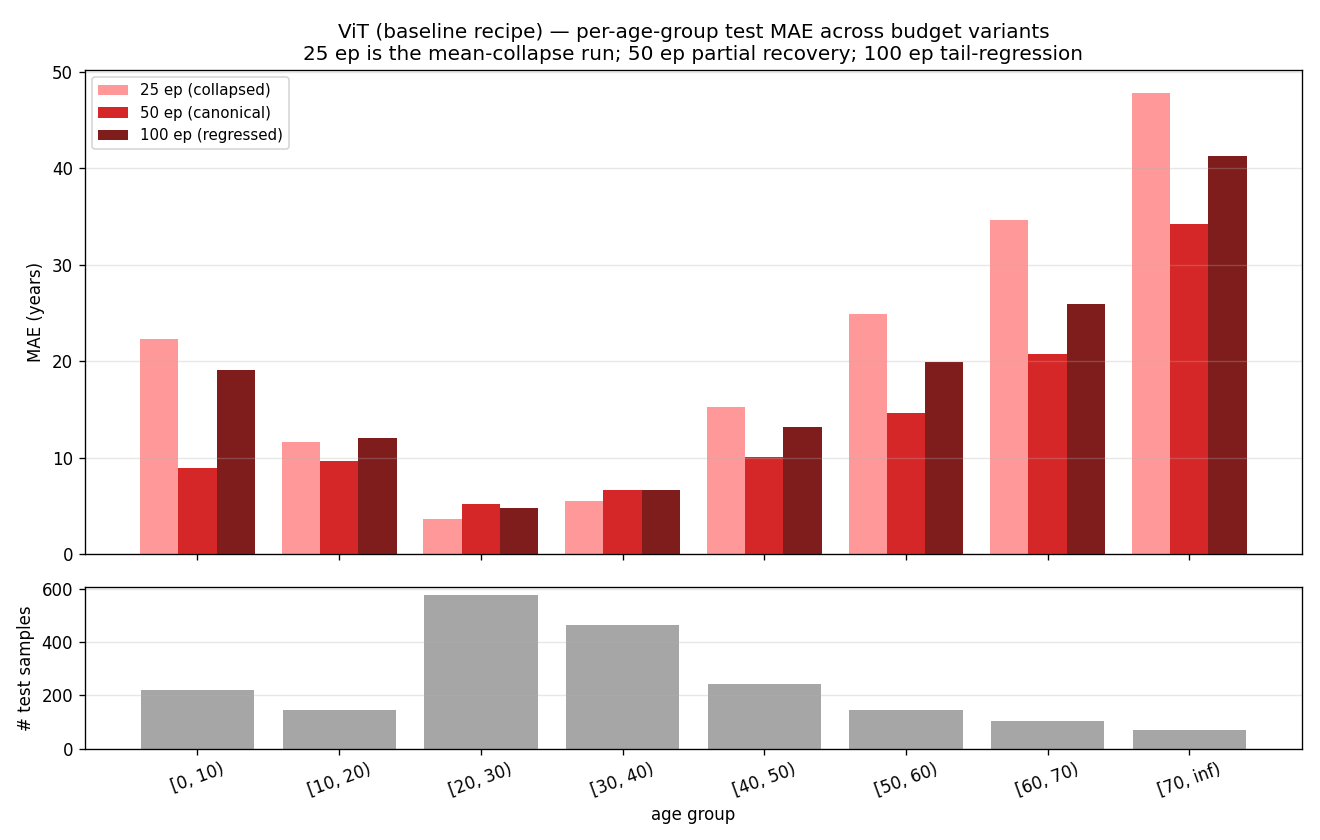

In [9]:
COMPARISON_DIR = PROJECT_ROOT / "results" / "comparison"
COMPARISON_TABLE = COMPARISON_DIR / "comparison_table.csv"

if COMPARISON_TABLE.exists():
    comparison_df = pd.read_csv(COMPARISON_TABLE)
    display(comparison_df)
else:
    print(f"Comparison table not found: {COMPARISON_TABLE}")

COMPARISON_ARTIFACTS = [
    ("scatter_three_panel.png", "Predicted vs. Ground Truth: Three-Panel Comparison"),
    ("pred_distribution.png", "Prediction Distribution Comparison"),
    ("per_age_bar.png", "Per-Age-Group MAE Comparison"),
    ("mae_curves_overlay.png", "Validation MAE Curves Overlay"),
    ("loss_curves_overlay.png", "Loss Curves Overlay"),
    ("budget_extension_mae_curves.png", "Budget Extension: MAE Curves"),
    ("budget_extension_baseline_per_age.png", "Budget Extension: Baseline Per-Age MAE"),
]

for file_name, title in COMPARISON_ARTIFACTS:
    image_path = COMPARISON_DIR / file_name
    if image_path.exists():
        display(Markdown(f"**{title}**"))
        display(Image(filename=str(image_path)))
    else:
        print(f"Missing comparison artifact: {image_path}")


## 7. 单模型结果图展示

本节展示预测值与真实值散点图、验证集 MAE 曲线和 loss 曲线。若本次没有重新运行测试集验证，则直接使用 `results/` 中已经保存的图片。

### densenet  (results\densenet)

**Predicted vs. Ground Truth**

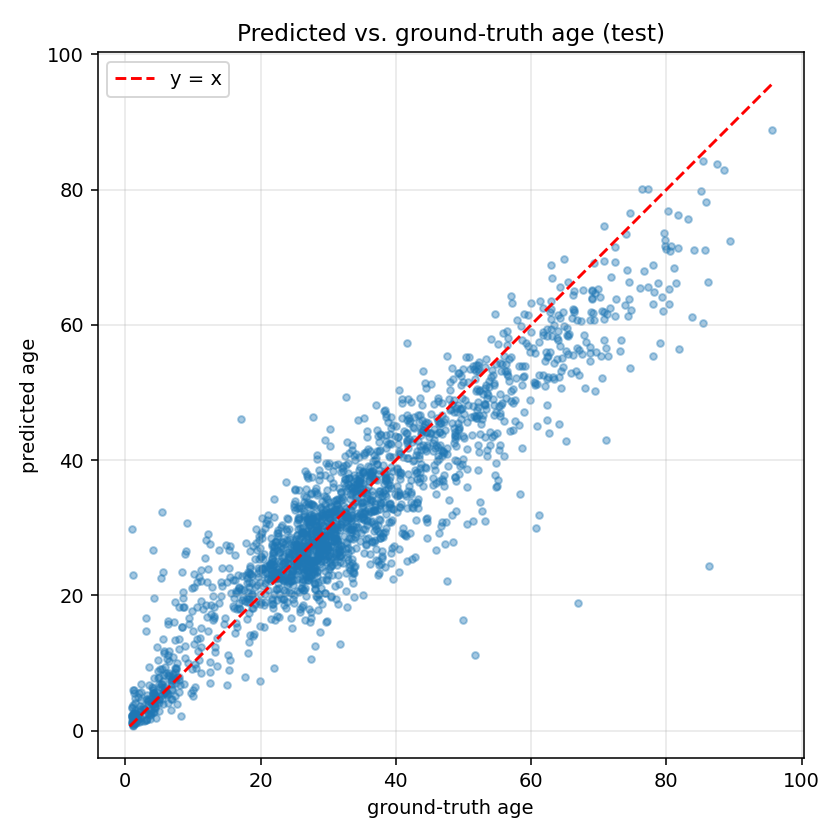

**Validation MAE Curve**

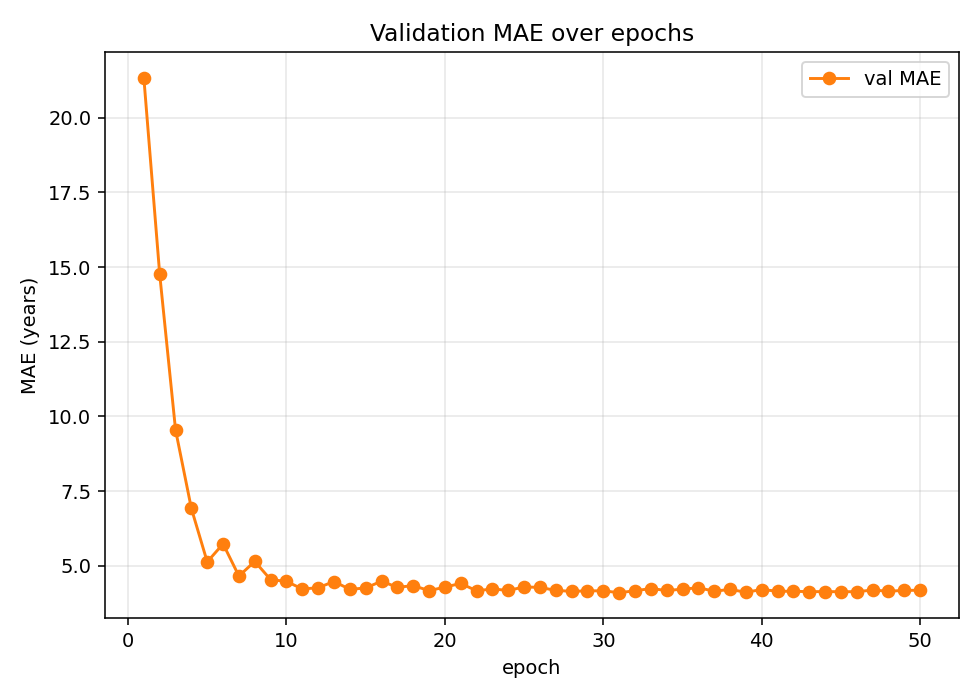

**Loss Curve**

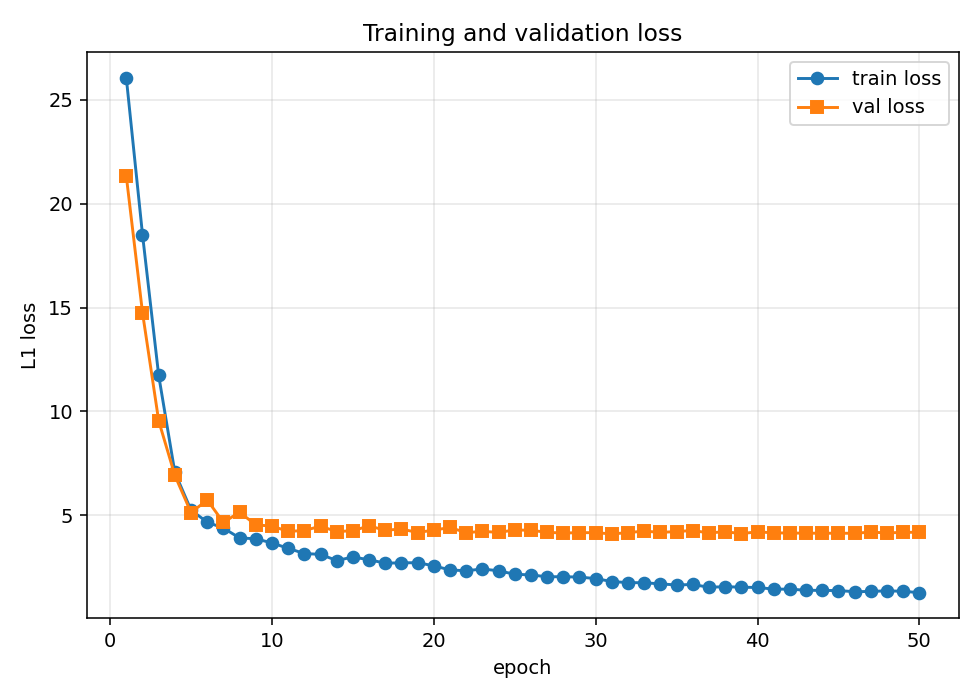

### vit  (results\vit)

**Predicted vs. Ground Truth**

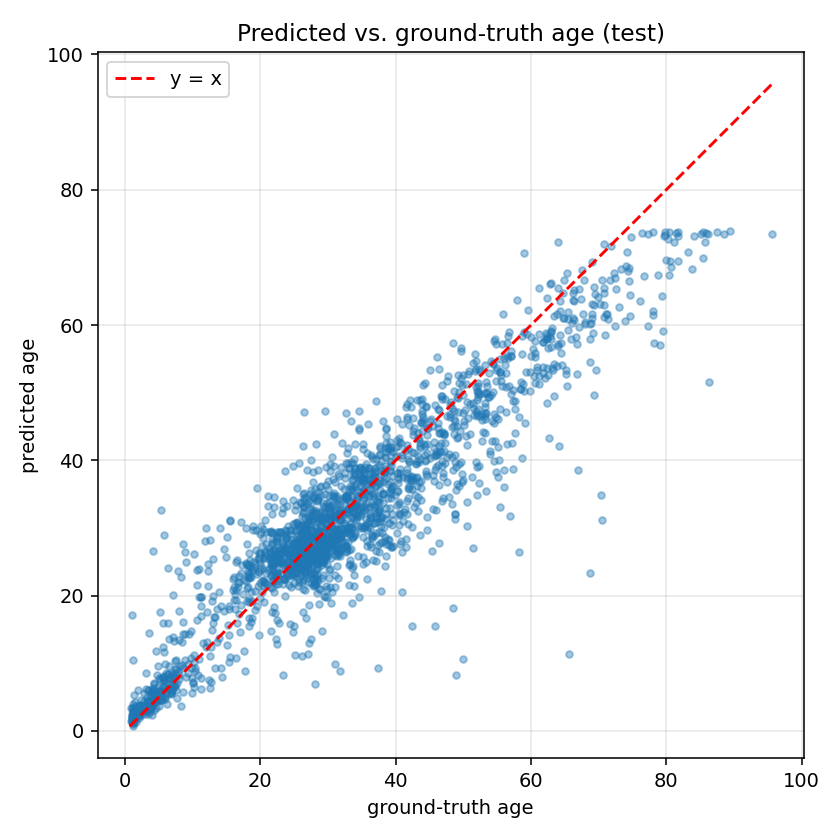

**Validation MAE Curve**

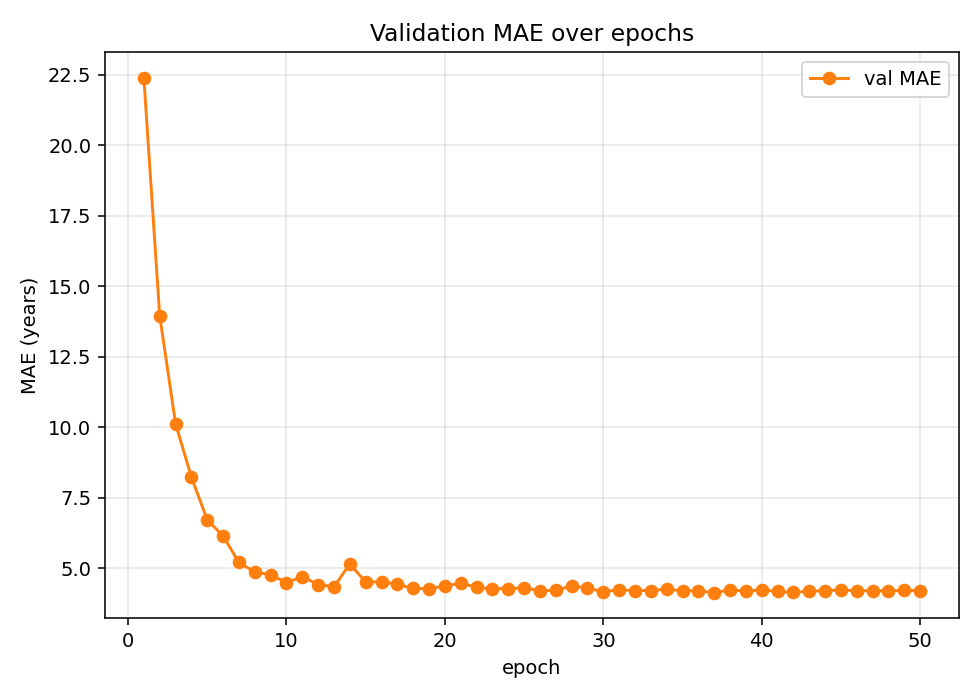

**Loss Curve**

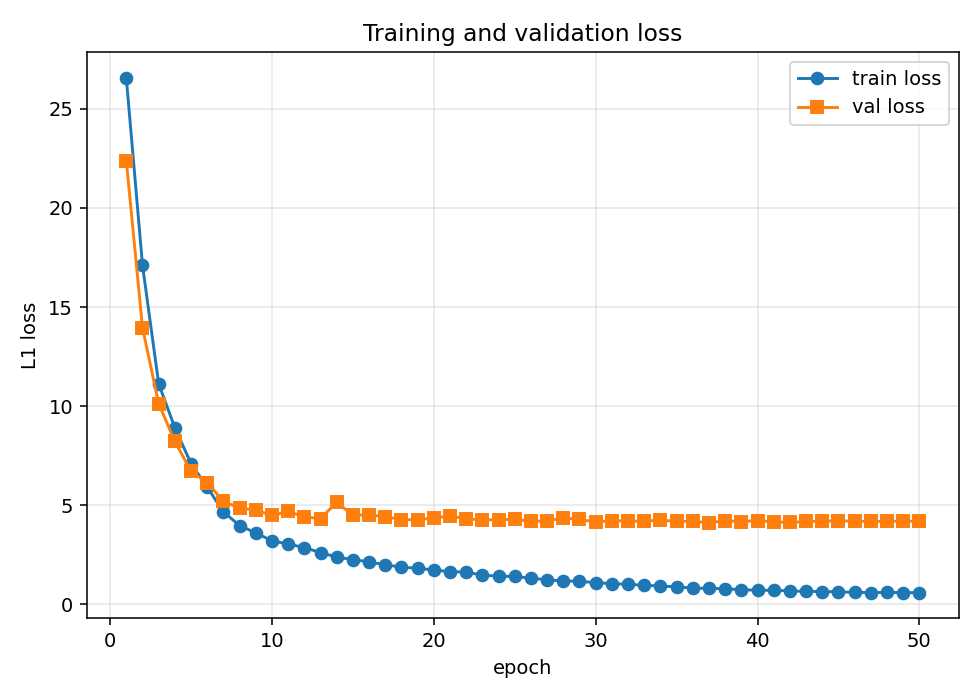

### vit_baseline  (results\vit_baseline)

**Predicted vs. Ground Truth**

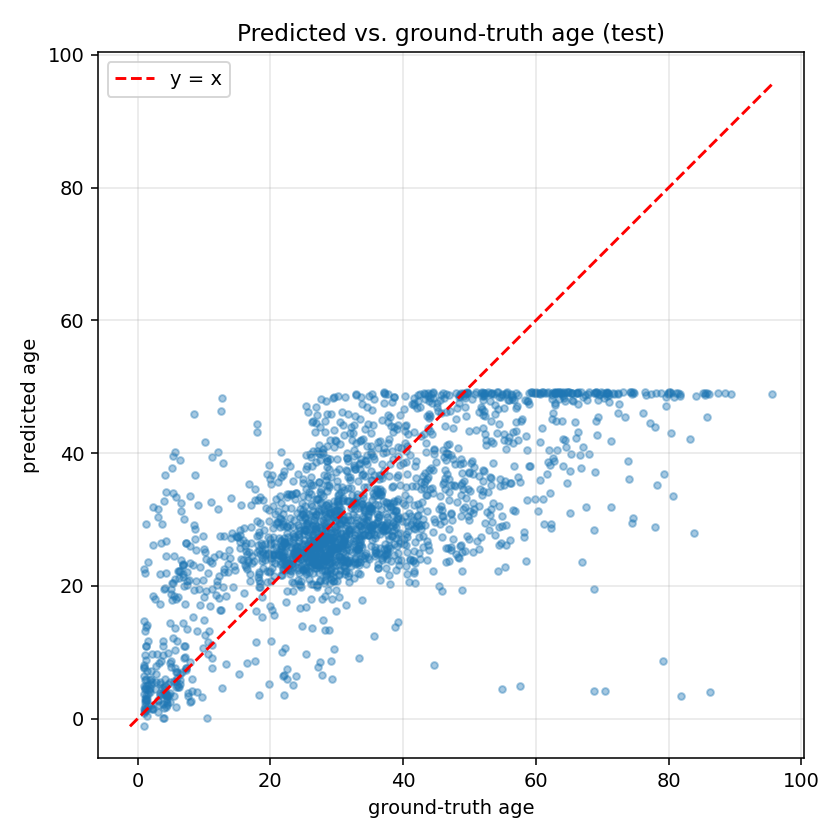

**Validation MAE Curve**

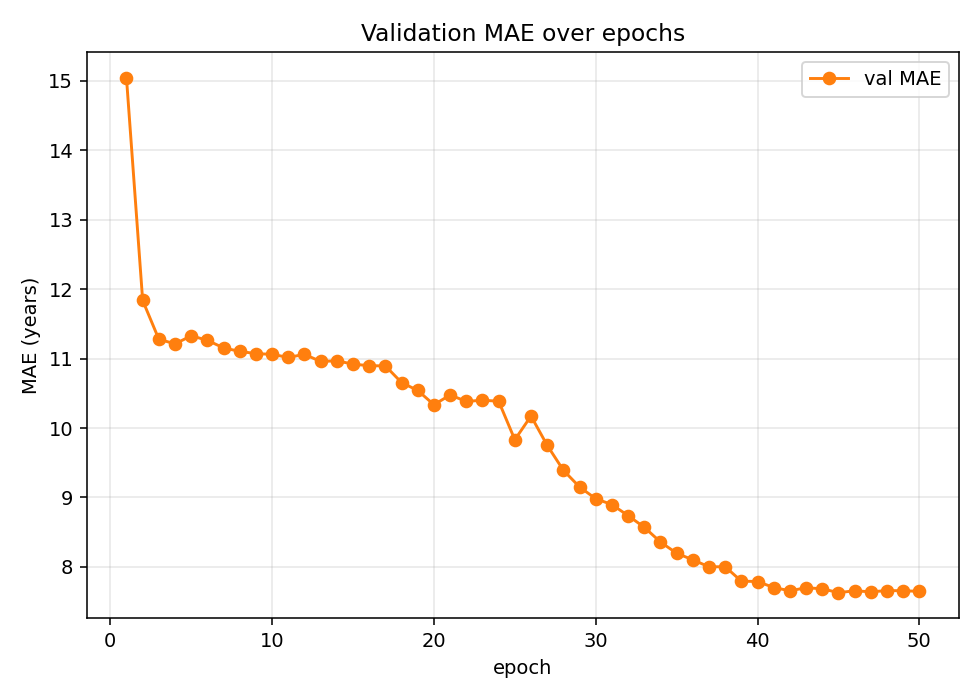

**Loss Curve**

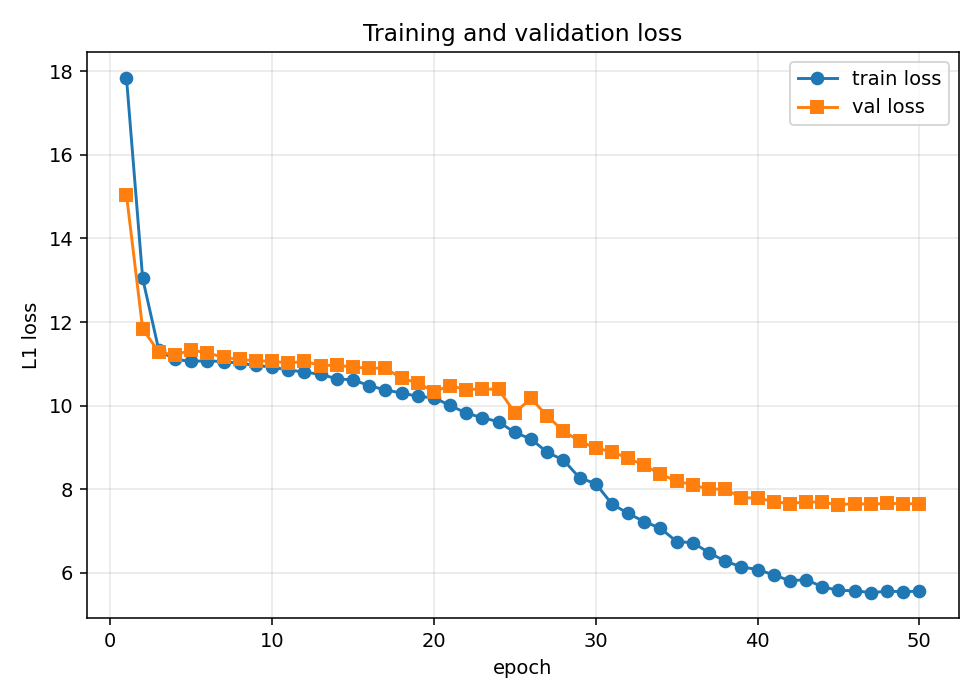

In [10]:
ARTIFACTS = [
    ("pred_vs_true_scatter.png", "Predicted vs. Ground Truth"),
    ("mae_curve.png", "Validation MAE Curve"),
    ("loss_curve.png", "Loss Curve"),
]

for model in MODELS:
    result_dir = find_model_result_dir(model)
    if result_dir is None:
        continue
    display(Markdown(f"### {model}  ({result_dir.relative_to(PROJECT_ROOT)})"))
    for file_name, title in ARTIFACTS:
        image_path = result_dir / file_name
        if image_path.exists():
            display(Markdown(f"**{title}**"))
            display(Image(filename=str(image_path)))


## 8. 最终模型现象验证（可选）

本节用于做最终展示性验证：由用户手动指定一张人脸图片，然后使用 DenseNet、ViT 和 ViT baseline 输出预测年龄，直观观察模型现象。

为了避免搜索项目中所有图片导致运行变慢，本节不会自动扫描图片。请手动设置 `IMAGE_PATH`，可以填写绝对路径、相对项目根目录的文件名，或包含图片的文件夹名。本节只进行前向推理，不训练、不反向传播、不修改模型参数。

torch 版本: 2.12.0+cpu
torchvision 版本: 0.27.0+cpu
是否可用 CUDA: False


**输入图片：`1-ME.jpg`**

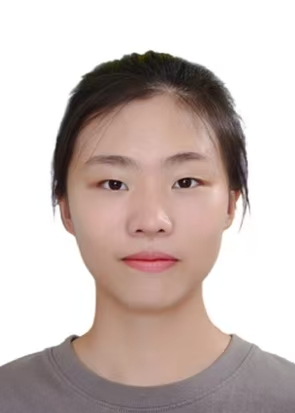

,模型,预测年龄
0,densenet,12.01
1,vit,15.58
2,vit_baseline,21.42


**输入图片：`2-LI.jpg`**

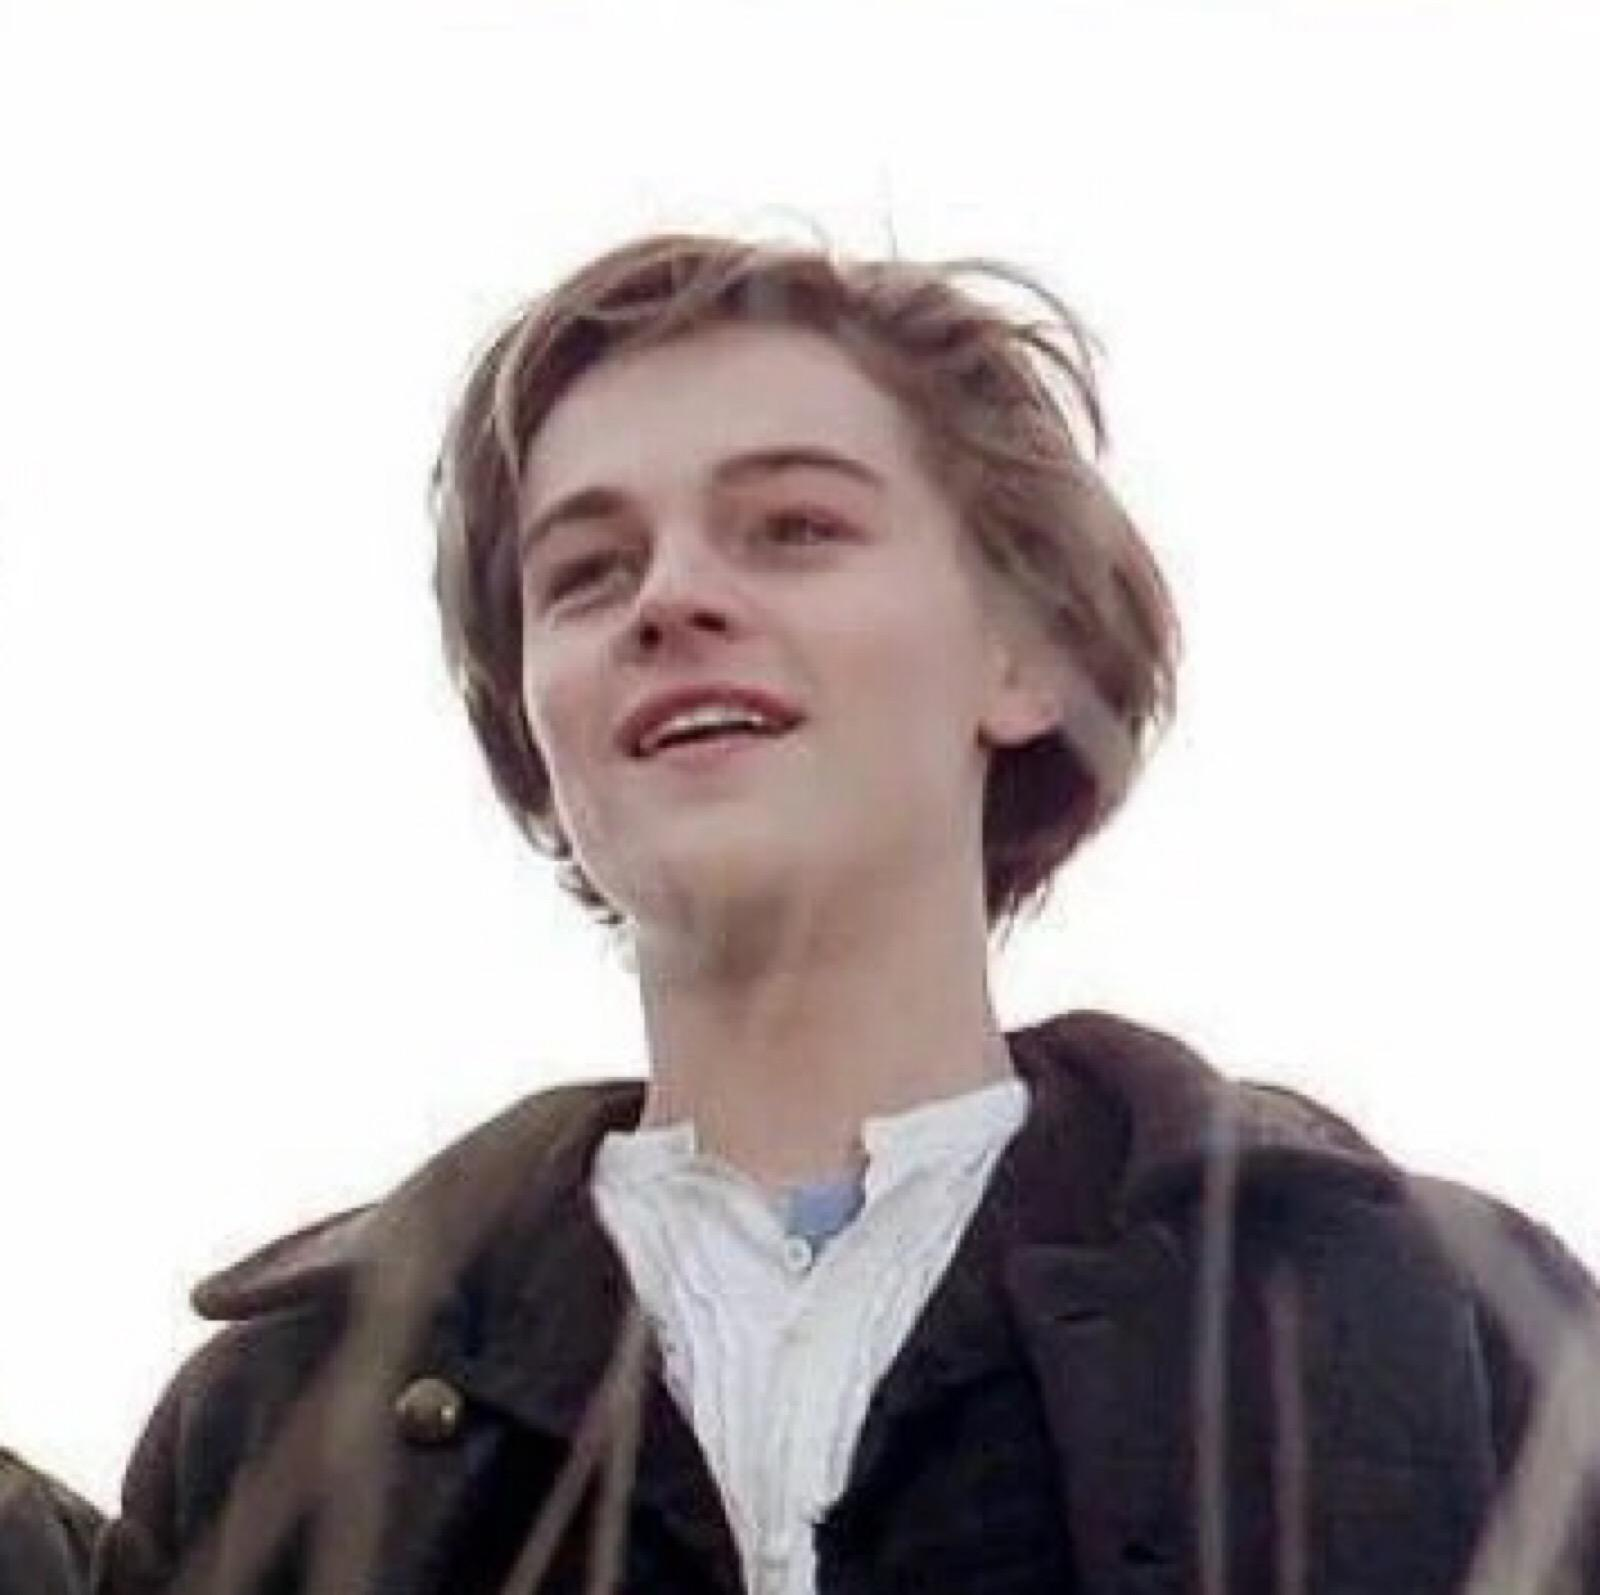

,模型,预测年龄
0,densenet,26.18
1,vit,22.66
2,vit_baseline,28.43


**输入图片：`3-ST.webp`**

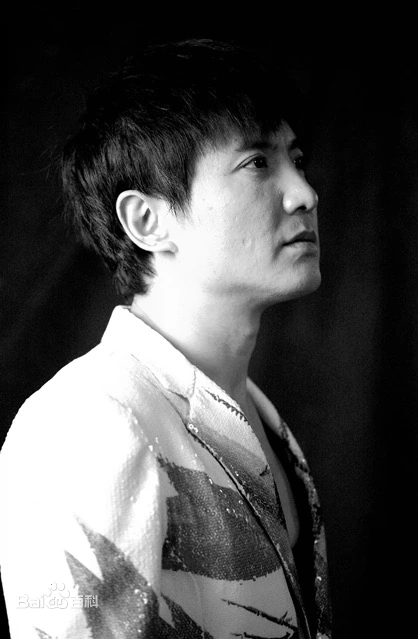

,模型,预测年龄
0,densenet,26.69
1,vit,26.42
2,vit_baseline,24.45


**输入图片：`4-ST43.webp`**

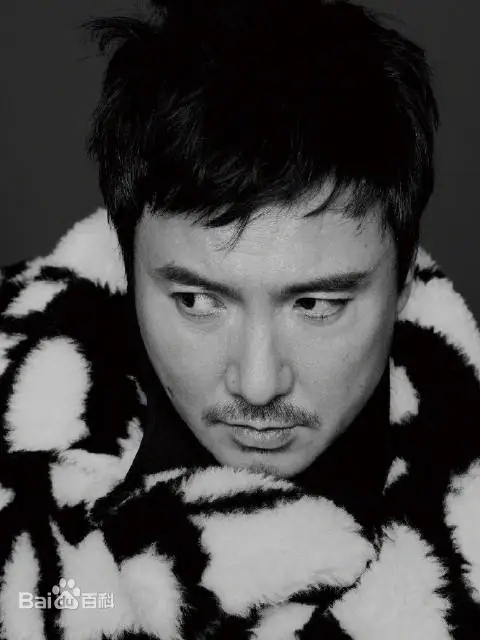

,模型,预测年龄
0,densenet,22.47
1,vit,19.07
2,vit_baseline,27.26


**输入图片：`5-ST43.webp`**

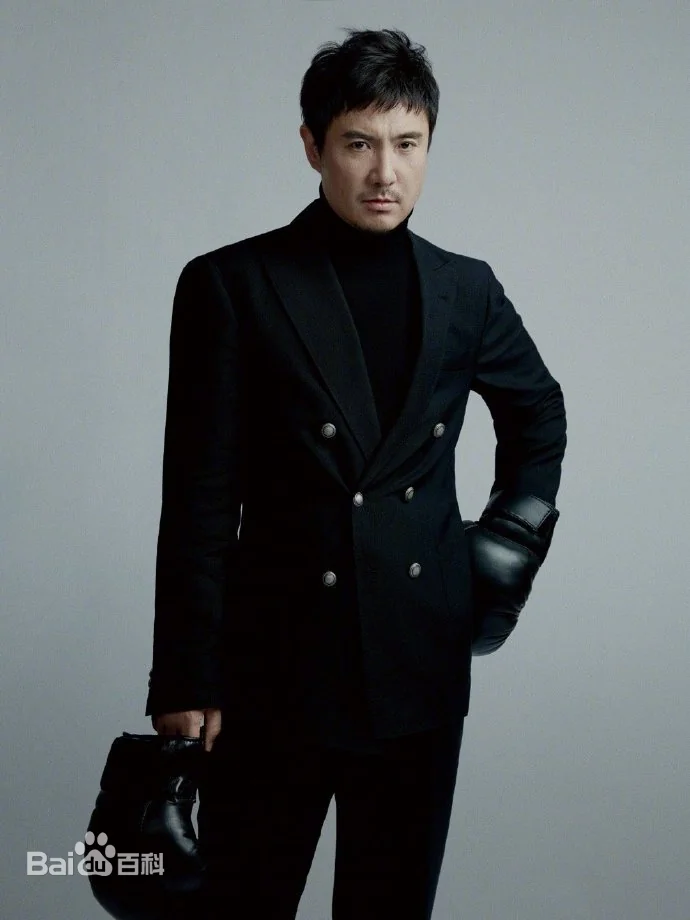

,模型,预测年龄
0,densenet,36.26
1,vit,36.63
2,vit_baseline,22.93


**输入图片：`6-ST43.jpg`**

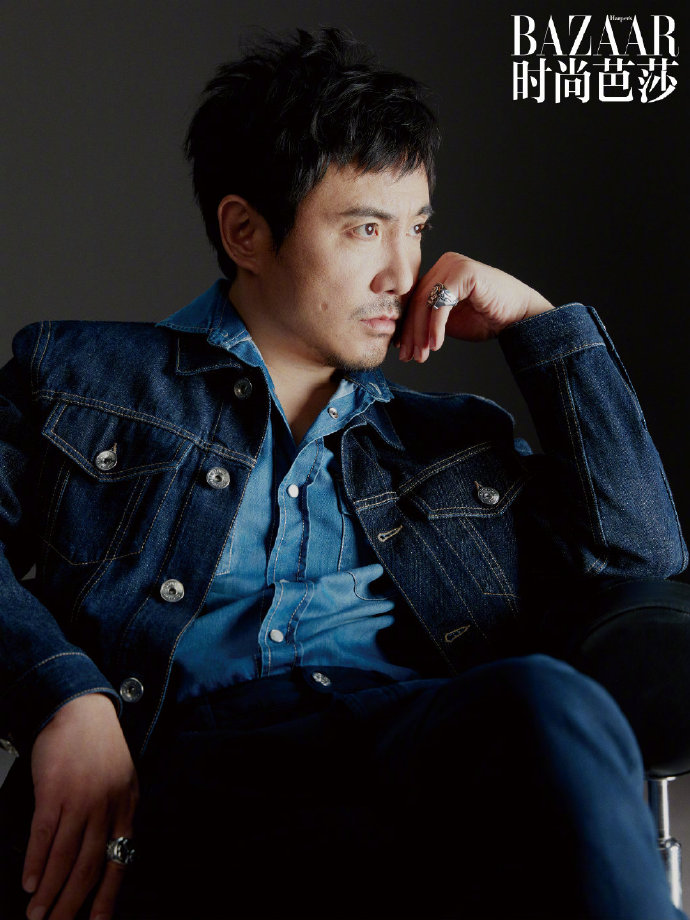

,模型,预测年龄
0,densenet,36.65
1,vit,24.08
2,vit_baseline,23.48


In [11]:
IMAGE_PATH =" "  # 示例：PROJECT_ROOT / "data" / "demo_face.jpg"，或 "1-ME.jpg"，或 "demo_images"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}


def resolve_image_paths(image_path) -> list[Path]:
    """Resolve a user-provided file or folder path without scanning the whole project."""
    if image_path is None:
        return []

    path = Path(image_path)
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    path = path.expanduser().resolve()

    if path.is_file():
        return [path]
    if path.is_dir():
        return sorted(
            p for p in path.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )
    raise FileNotFoundError(f"IMAGE_PATH 不存在：{path}")


def predict_one_image(image_path: Path, models: list[str]) -> pd.DataFrame:
    import torch
    from PIL import Image as PILImage
    from src.dataset import build_transform
    from src.models import build_model

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    transform = build_transform(224, train=False)
    image = PILImage.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    rows = []
    for model_name in models:
        ckpt_path = NOTEBOOK_CKPT_DIR / f"{model_name}_best.pth"
        model = build_model(model_name, pretrained=False).to(device)
        payload = torch.load(ckpt_path, map_location=device)
        state_dict = payload["state_dict"] if isinstance(payload, dict) and "state_dict" in payload else payload
        model.load_state_dict(state_dict, strict=True)
        model.eval()
        with torch.no_grad():
            pred_age = float(model(x).squeeze().detach().cpu().item())
        rows.append({"模型": model_name, "预测年龄": round(pred_age, 2)})
    return pd.DataFrame(rows)


if IMAGE_PATH is not None:
    ensure_runtime_dependencies(required=True, include_torch=True)
    prepare_checkpoints(MODELS)
    image_paths = resolve_image_paths(IMAGE_PATH)
    if not image_paths:
        print("未找到可用图片。")
    for image_path in image_paths:
        display(Markdown(f"**输入图片：`{image_path.name}`**"))
        display(Image(filename=str(image_path), width=220))
        display(predict_one_image(image_path, MODELS))
else:
    print("IMAGE_PATH 未设置，跳过最终模型现象验证。")
